<a href="https://colab.research.google.com/github/SRET-College/Sem-6-NN-and-DL/blob/main/NN_and_DL_Expt_3B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import tensorflow_datasets as tfds

print("Loading Eminst Letters dataset...")
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/letters',
    split = ['train', 'test'],
    shuffle_files = True,
    as_supervised = True,
    with_info = True
)

Loading Eminst Letters dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.1ZF82X_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.1ZF82X_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


In [ ]:
def preprocessing_emnist(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.transpose(image)
    return image, label - 1

In [ ]:
train_data = ds_train.map(preprocessing_emnist).batch(32).prefetch(tf.data.AUTOTUNE)
test_data = ds_test.map(preprocessing_emnist).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
with tf.device('/GPU:0'):
  model = Sequential([
      Flatten(input_shape = [28, 28, 1]),
      Dense(256, activation = 'relu'),
      Dropout(0.2),
      Dense(128, activation = 'relu'),
      Dense(26, activation = "softmax")
  ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
print("Starting Training on 26 Letter Classes...")

Starting Training on 26 Letter Classes...


In [ ]:
history = model.fit(train_data,epochs = 10, validation_data = test_data)

Epoch 1/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 30s 10ms/step - accuracy: 0.6723 - loss: 1.1099 - val_accuracy: 0.8441 - val_loss: 0.4846
Epoch 2/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 34s 8ms/step - accuracy: 0.8493 - loss: 0.4774 - val_accuracy: 0.8701 - val_loss: 0.4035
Epoch 3/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8739 - loss: 0.3917 - val_accuracy: 0.8760 - val_loss: 0.3811
Epoch 4/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8860 - loss: 0.3447 - val_accuracy: 0.8774 - val_loss: 0.3739
Epoch 5/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.8934 - loss: 0.3216 - val_accuracy: 0.8851 - val_loss: 0.3576
Epoch 6/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - accuracy: 0.8993 - loss: 0.2962 - val_accuracy: 0.8832 - val_loss: 0.3717
Epoch 7/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9038 - loss: 0.2802 - val_accuracy: 0.8911 - val_loss: 0.3411
Epoch 8/10
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.9113 - loss: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


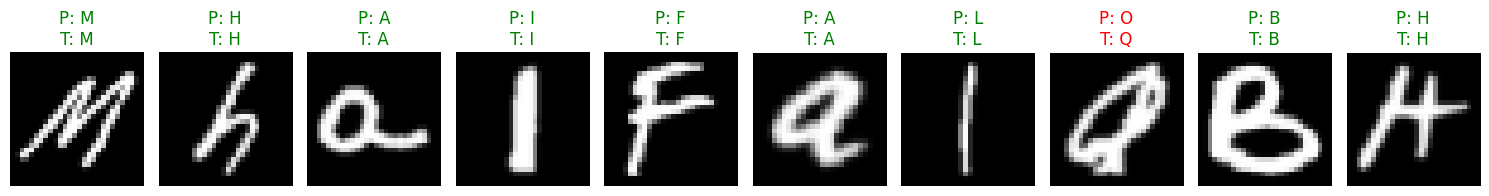

In [ ]:
def get_letter(label):
  return chr(ord('A') + label)

images, labels = next(iter(test_data))
predictions = model.predict(images)
plt.figure(figsize=(15, 4))

for i in range(10):
  plt.subplot(1, 10, i + 1)
  plt.imshow(images[i].numpy().squeeze(), cmap='gray')
  pred_idx = np.argmax(predictions[i])
  true_idx = labels[i].numpy()

  color = 'green' if pred_idx == true_idx else 'red'
  plt.title(f"P: {get_letter(pred_idx)}\nT: {get_letter(true_idx)}", color = color)
  plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_data, verbose = 0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Loss: 0.3506
Test Accuracy: 89.10%
